# Análisis Exploratorio de Datos (EDA)

**Proyecto:** Sistema de Recomendación para E-commerce  
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Objetivo:** Responder las preguntas abiertas del ETL y validar que las variables 
y macrogrupos construidos tienen el comportamiento esperado para el modelado.

**Preguntas a responder:**
1. ¿Los macrogrupos tienen comportamientos internamente coherentes?
2. ¿Existe co-ocurrencia suficiente entre grupos para construir patrones confiables?
3. ¿Hay patrones temporales relevantes en el comportamiento de compra?
4. ¿El ticket promedio varía significativamente entre grupos?
5. ¿La satisfacción del cliente difiere entre macrogrupos?

---

## 1. Configuración e Importación de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
from pathlib import Path
import pandas as pd

BASE_PATH = Path.cwd().parent / "data" / "processed"

if not BASE_PATH.exists():
    raise FileNotFoundError(f"No se encontró la ruta: {BASE_PATH}")

df_model_path = BASE_PATH / "df_model.csv"

if not df_model_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {df_model_path}")

df_model = pd.read_csv(df_model_path)

print(f"Dataset cargado: {df_model.shape}")
print(f"Columnas: {df_model.columns.tolist()}")

Dataset cargado: (112915, 18)
Columnas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_purchase_timestamp', 'order_status', 'product_category_name_english', 'grupo_categoria', 'review_score', 'year', 'month', 'day_of_week', 'hour', 'time_of_day']


El dataset procesado contiene 112.915 registros y 18 columnas. 
Incluye variables transaccionales, de producto, temporales y de satisfacción. 
El EDA se organiza en dos bloques:

1. **Comportamiento general del marketplace** — contexto a nivel de categoría individual
2. **Análisis por macrogrupos** — responde las 5 preguntas abiertas del ETL, 
insumo directo para el modelado

## 2. Comportamiento General del Marketplace

Para interpretar correctamente los análisis por macrogrupos, primero se establece 
el contexto general del catálogo. Aunque el ETL ya analizó la cardinalidad de categorías 
para fundamentar la agrupación, aquí el objetivo es distinto: **entender el comportamiento 
del marketplace como un todo** — cómo se distribuyen los precios, qué tan satisfechos 
están los clientes y cómo compran — antes de profundizar en los grupos.

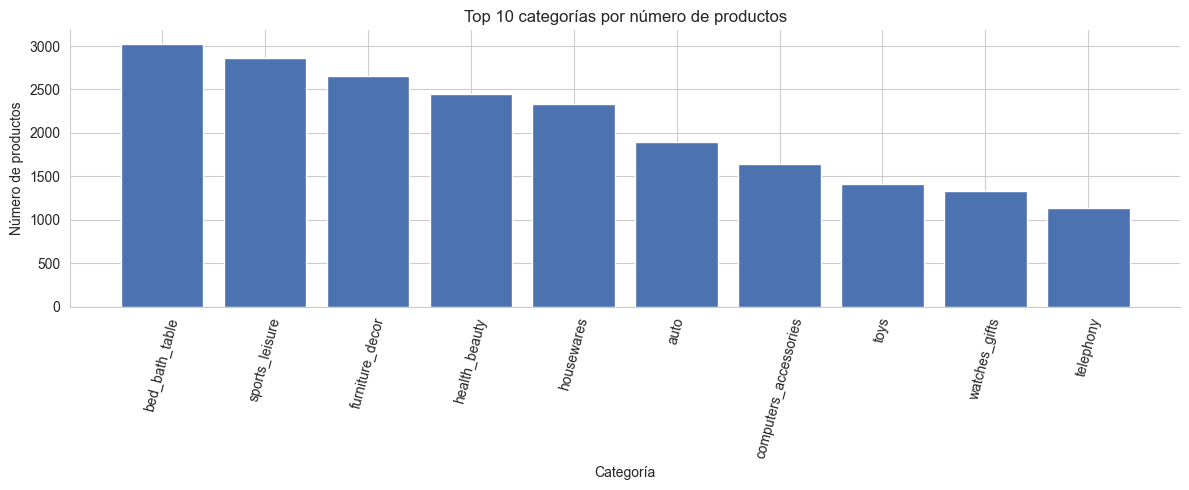

In [3]:
sns.set_style('whitegrid')
# Top 10 categorías por número de productos únicos
top_cats = (
    df_model.dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')['product_id']
    .nunique()
    .reset_index(name='numero_productos')
    .sort_values('numero_productos', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
plt.bar(top_cats['product_category_name_english'], top_cats['numero_productos'], color='#4C72B0')
plt.xticks(rotation=75)
plt.title('Top 10 categorías por número de productos')
plt.xlabel('Categoría')
plt.ylabel('Número de productos')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

La oferta se concentra en categorías de hogar y estilo de vida, con bed_bath_table, 
sports_leisure y furniture_decor liderando en número de productos. 
Esto confirma que el catálogo tiene una orientación clara hacia el consumo doméstico y personal. 
pet_shop no aparece en el top 10 — es un segmento especializado de tamaño medio.

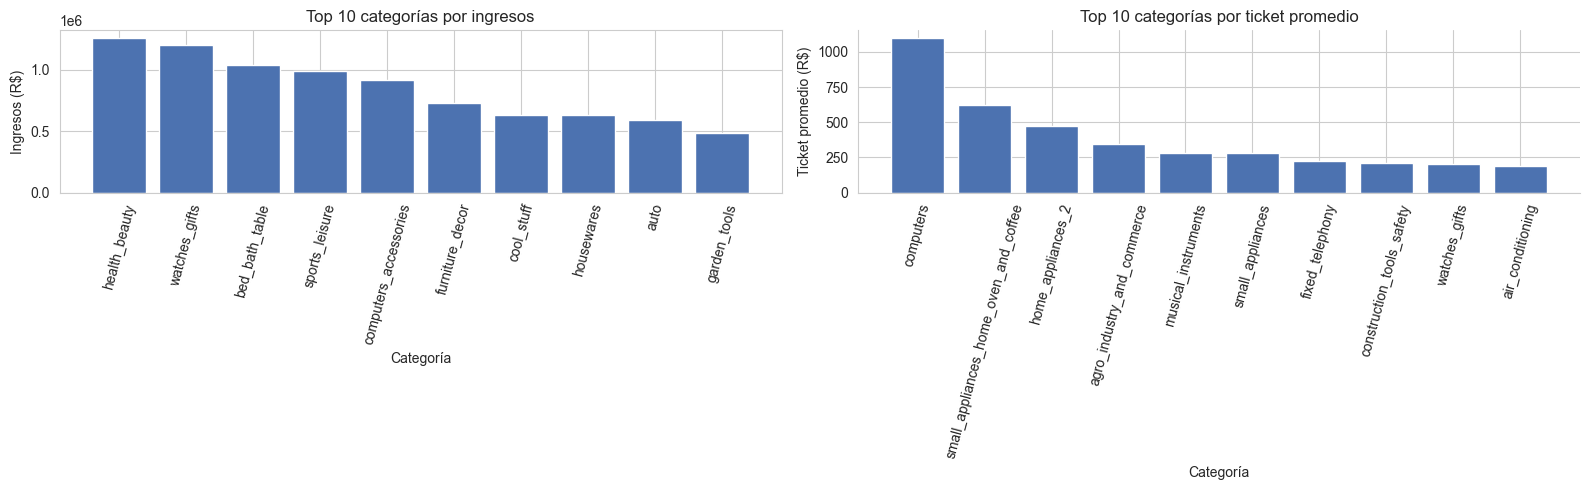

In [4]:
sns.set_style('whitegrid')
# Ingresos totales y ticket promedio por categoría
metricas_cat = (
    df_model.dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(ingresos=('price','sum'), ticket=('price','mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_ingresos = metricas_cat.sort_values('ingresos', ascending=False).head(10)
axes[0].bar(top_ingresos['product_category_name_english'], top_ingresos['ingresos'], color='#4C72B0')
axes[0].set_title('Top 10 categorías por ingresos')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Ingresos (R$)')
axes[0].tick_params(axis='x', rotation=75)

top_ticket = metricas_cat.sort_values('ticket', ascending=False).head(10)
axes[1].bar(top_ticket['product_category_name_english'], top_ticket['ticket'], color='#4C72B0')
axes[1].set_title('Top 10 categorías por ticket promedio')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Ticket promedio (R$)')
axes[1].tick_params(axis='x', rotation=75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Las categorías con más ingresos no son las de mayor ticket promedio. Health_beauty y watches_gifts lideran en ingresos por volumen de ventas, mientras que computers y electrodomésticos tienen el mayor ticket por producto. **Esto muestra que ingresos, volumen y valor son dimensiones independientes** — un hallazgo que guiará cómo se combinan estas variables en el modelo de recomendación.

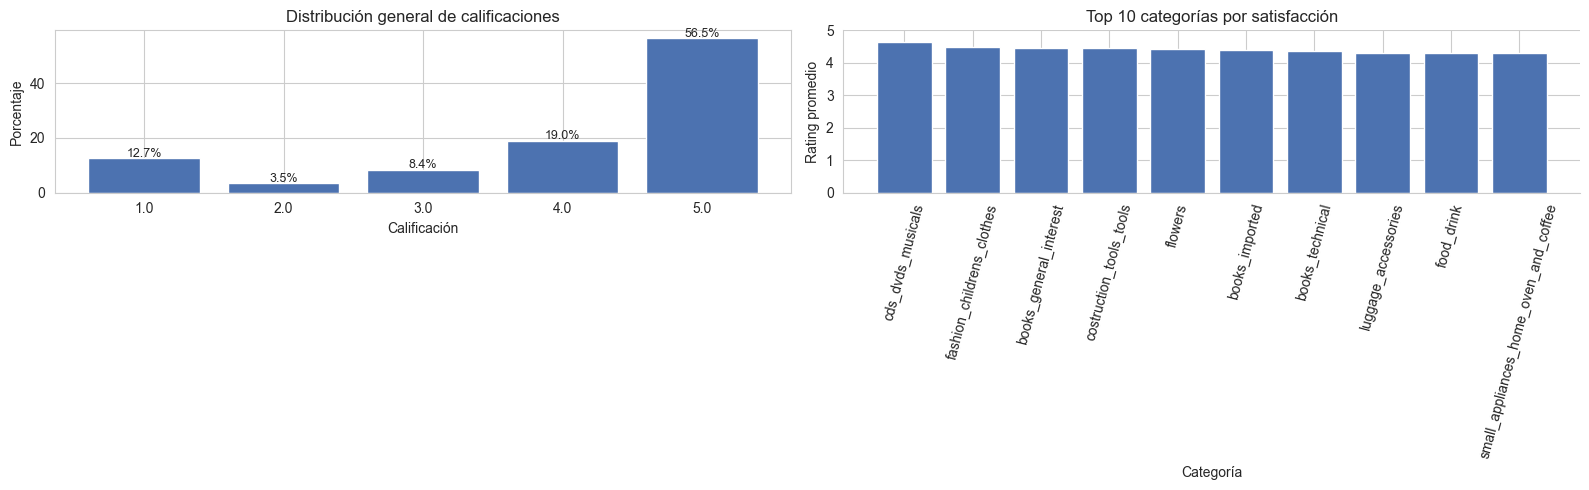

Distribución porcentual:
review_score
1.0    12.7
2.0     3.5
3.0     8.4
4.0    19.0
5.0    56.5


In [5]:
sns.set_style('whitegrid')
# Satisfacción general y top 10 categorías mejor calificadas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución general de scores
score_dist = df_model['review_score'].value_counts(normalize=True).sort_index() * 100
axes[0].bar(score_dist.index.astype(str), score_dist.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución general de calificaciones')
axes[0].set_xlabel('Calificación')
axes[0].set_ylabel('Porcentaje')
for i, v in enumerate(score_dist.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Top 10 categorías mejor calificadas
top_reviews = (
    df_model.dropna(subset=['product_category_name_english','review_score'])
    .groupby('product_category_name_english')['review_score']
    .mean().reset_index()
    .sort_values('review_score', ascending=False).head(10)
)
axes[1].bar(top_reviews['product_category_name_english'], top_reviews['review_score'], color='#4C72B0')
axes[1].set_title('Top 10 categorías por satisfacción')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Rating promedio')
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Distribución porcentual:')
print(score_dist.round(1).to_string())

El 75% de las calificaciones son 4 o 5 estrellas — el marketplace tiene una base sólida de satisfacción. 
Las categorías mejor calificadas no son las más vendidas ni las más caras: 
cds_dvds_musicals y fashion_childrens_clothes lideran en satisfacción pero son nichos pequeños. 
**Satisfacción, volumen y valor son tres dimensiones independientes** — 
ninguna predice a las otras.

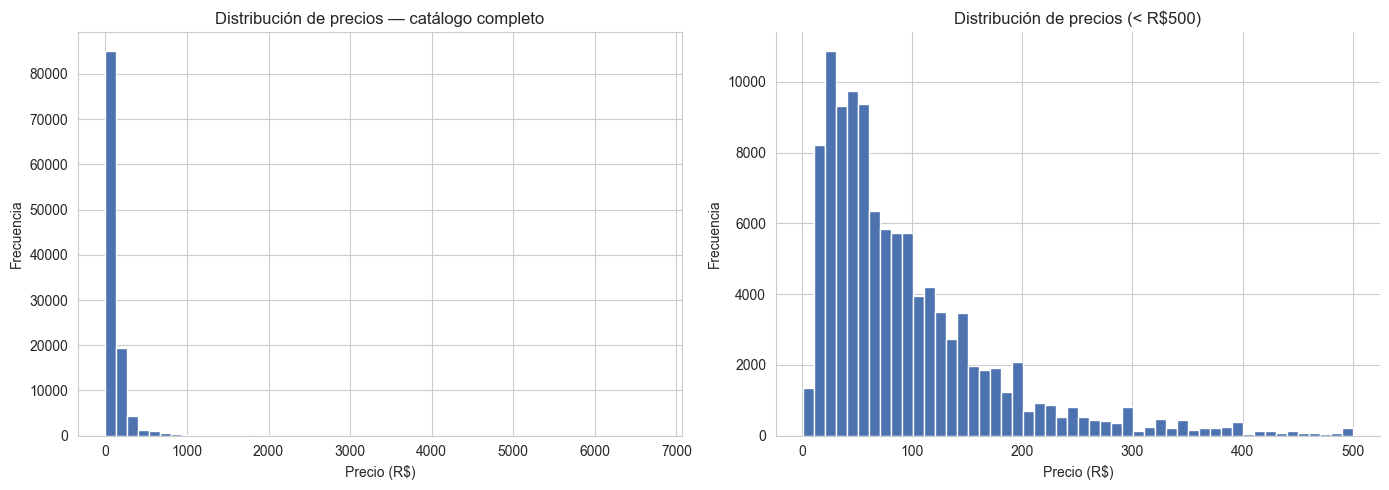

count    112915.00
mean        120.57
std         183.47
min           0.85
25%          39.90
50%          74.90
75%         134.90
max        6735.00
Name: price, dtype: float64


In [6]:
sns.set_style('whitegrid')
# Distribución de precios del catálogo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model['price'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de precios — catálogo completo')
axes[0].set_xlabel('Precio (R$)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_model[df_model['price']<500]['price'], bins=50, color='#4C72B0', edgecolor='white')
axes[1].set_title('Distribución de precios (< R$500)')
axes[1].set_xlabel('Precio (R$)')
axes[1].set_ylabel('Frecuencia')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(df_model['price'].describe().round(2))

El catálogo tiene una fuerte asimetría positiva: la mayoría de transacciones están por debajo de R$200, 
con una cola de productos de alto valor. Esta distribución es estructural del marketplace, 
no una característica exclusiva de pet_shop. 
El ticket promedio general (~R$110) refleja esta distribución asimétrica.

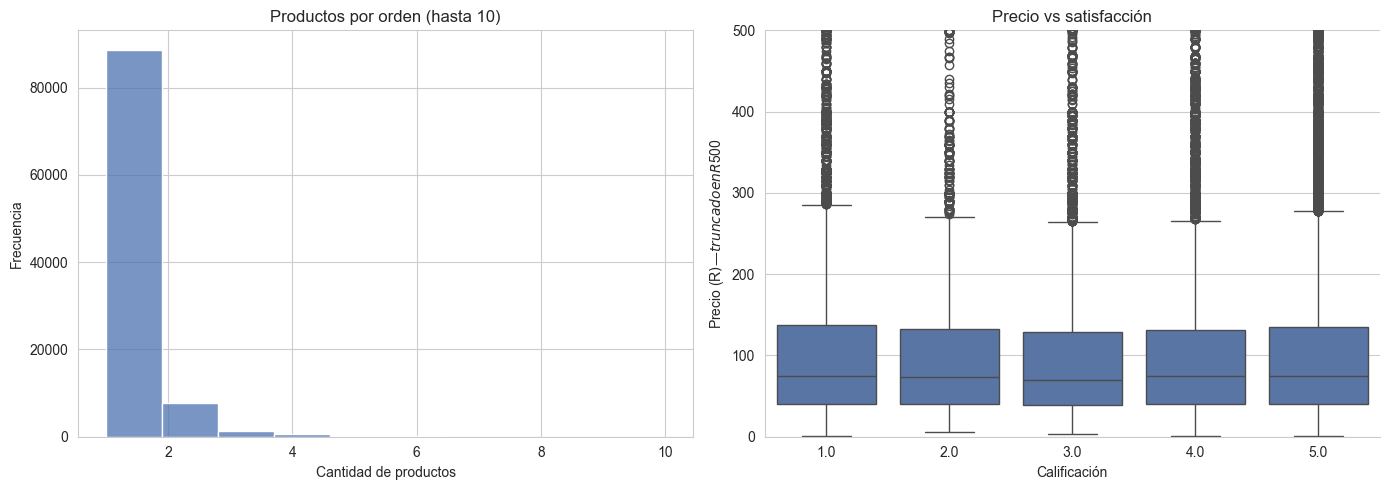

Órdenes con 1 producto:   88,704 (89.9%)
Órdenes con 2+ productos: 9,962 (10.1%)
Correlación precio-score: -0.004


In [7]:
sns.set_style('whitegrid')
# Productos por orden y precio vs satisfacción
productos_por_orden = df_model.groupby('order_id')['order_item_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(productos_por_orden[productos_por_orden<=10], bins=10, ax=axes[0], color='#4C72B0')
axes[0].set_title('Productos por orden (hasta 10)')
axes[0].set_xlabel('Cantidad de productos')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x='review_score', y='price',
            data=df_model.dropna(subset=['review_score','price']),
            ax=axes[1], color='#4C72B0')
axes[1].set_ylim(0, 500)
axes[1].set_title('Precio vs satisfacción')
axes[1].set_xlabel('Calificación')
axes[1].set_ylabel('Precio (R$) — truncado en R$500')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Órdenes con 1 producto:   {(productos_por_orden==1).sum():,} ({(productos_por_orden==1).mean()*100:.1f}%)')
print(f'Órdenes con 2+ productos: {(productos_por_orden>1).sum():,} ({(productos_por_orden>1).mean()*100:.1f}%)')
corr = df_model[['price','review_score']].corr().iloc[0,1]
print(f'Correlación precio-score: {corr:.3f}')

Dos hallazgos estructurales del dataset que determinan el diseño del modelo:

**1. La gran mayoría de órdenes tienen un solo producto** — confirma la limitación de co-ocurrencia 
identificada en el análisis inicial. El sistema no puede basarse en comportamiento dentro de una orden, 
sino en patrones colectivos entre muchos clientes.

**2. El precio no determina la satisfacción** (correlación ~0) — el ticket promedio se usará 
como variable de valor económico, no como indicador de calidad del producto.

### Síntesis: lo que aprendimos del marketplace general

| Dimensión | Hallazgo clave |
|---|---|
| Catálogo | Concentrado en hogar y estilo de vida, con alta cardinalidad (~70 categorías) |
| Precios | Fuerte asimetría — mayoría por debajo de R$200, media ~R$110 |
| Compras | ~90% de órdenes tienen 1 solo producto |
| Satisfacción | Alta y generalizada — 75% de calificaciones son 4 o 5 estrellas |
| Independencia | Volumen, valor y satisfacción son dimensiones independientes entre sí |

Con este contexto establecido, el análisis pasa a nivel de **macrogrupos** — 
la unidad de análisis del modelo de recomendación.

## 3. Pregunta 1: ¿Los macrogrupos tienen comportamientos coherentes?

La primera validación es confirmar que los 11 macrogrupos creados en el ETL 
efectivamente agrupan categorías con comportamientos similares y se diferencian entre sí. 
Si los grupos no son coherentes, el modelo de recomendación no tendría base sólida.

In [8]:
# Resumen consolidado por macrogrupo (excluye 'other')
resumen = (
    df_model[df_model['grupo_categoria'] != 'other']
    .groupby('grupo_categoria')
    .agg(
        ordenes=('order_id','nunique'),
        ingresos=('price','sum'),
        ticket_promedio=('price','mean'),
        rating_promedio=('review_score','mean'),
        productos_unicos=('product_id','nunique')
    )
    .round(2)
    .sort_values('ordenes', ascending=False)
    .reset_index()
)

print('=== RESUMEN POR MACROGRUPO ===')
print(resumen.to_string(index=False))

=== RESUMEN POR MACROGRUPO ===
          grupo_categoria  ordenes   ingresos  ticket_promedio  rating_promedio  productos_unicos
                    Hogar    30171 3921400.70           106.16             3.94             10687
               Recreación    19780 2735866.18           126.72             4.12              6705
               Tecnología    15311 1898587.98           110.22             3.95              3820
         Cuidado Personal    12013 1660798.09           126.31             4.14              3324
                     Moda     7993 1405796.67           163.45             4.05              2523
                Automotor     3897  592918.45           139.81             4.06              1900
       Viaje y accesorios     3340  371434.20           102.86             4.23              1198
 Industria y construcción     1813  376747.17           170.40             4.06               843
Cultura y entretenimiento     1798  303165.67           157.82             4.25        

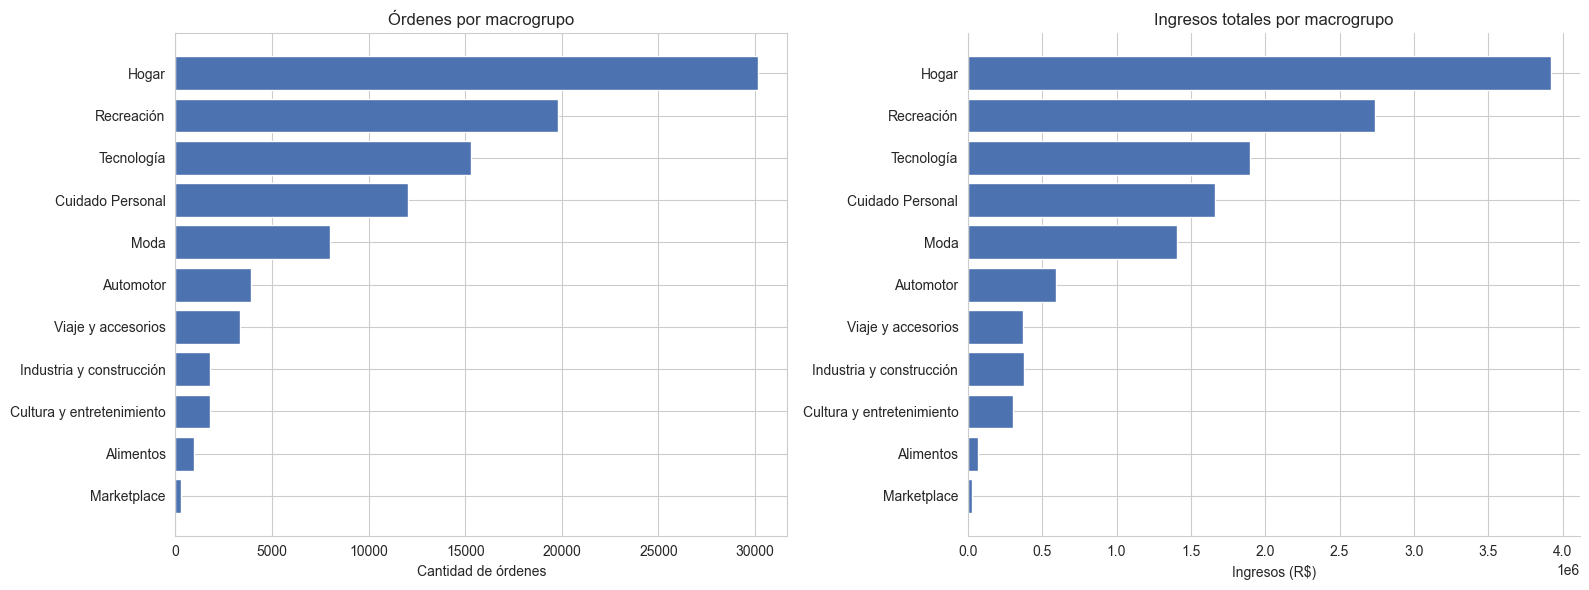

In [9]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(resumen['grupo_categoria'], resumen['ordenes'], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Órdenes por macrogrupo')
axes[0].set_xlabel('Cantidad de órdenes')

axes[1].barh(resumen['grupo_categoria'], resumen['ingresos'], color='#4C72B0')
axes[1].invert_yaxis()
axes[1].set_title('Ingresos totales por macrogrupo')
axes[1].set_xlabel('Ingresos (R$)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Los macrogrupos muestran perfiles claramente diferenciados:

- **Hogar y Recreación** lideran en volumen de órdenes e ingresos — son los grupos dominantes
- **Industria, Moda y Cultura** tienen tickets más altos pero menor volumen — segmentos de valor
- **Alimentos y Marketplace** son los más pequeños en todas las métricas

Ningún grupo es redundante con otro, lo que confirma que la agrupación del ETL fue coherente. 
**Sí, los macrogrupos tienen comportamientos coherentes.**

## 4. Pregunta 4: ¿El ticket promedio varía significativamente entre grupos?

Esta variable es crítica para el modelo: se usará para ponderar las recomendaciones, 
priorizando grupos de mayor valor económico.

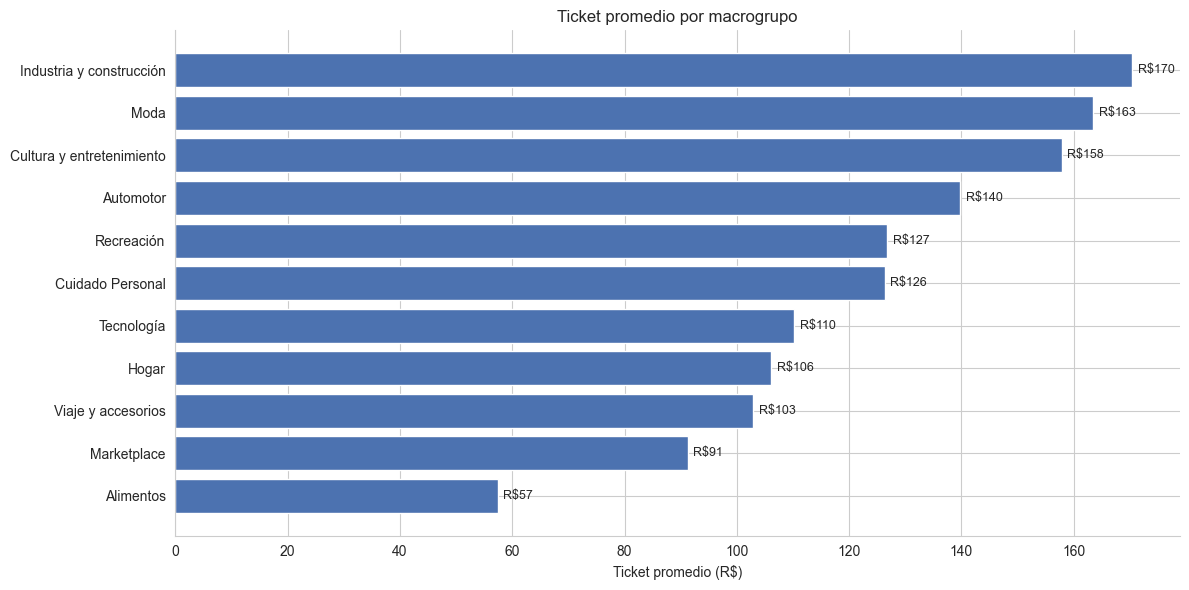

Mayor ticket: Industria y construcción (R$170.40)
Menor ticket: Alimentos (R$57.40)
Diferencia:   3.0x


In [10]:
sns.set_style('whitegrid')
ticket_orden = resumen.sort_values('ticket_promedio', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(ticket_orden['grupo_categoria'], ticket_orden['ticket_promedio'], color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Ticket promedio por macrogrupo')
plt.xlabel('Ticket promedio (R$)')
for bar, val in zip(bars, ticket_orden['ticket_promedio']):
    plt.text(val+1, bar.get_y()+bar.get_height()/2, f'R${val:.0f}', va='center', fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Mayor ticket: {ticket_orden.iloc[0]['grupo_categoria']} (R${ticket_orden.iloc[0]['ticket_promedio']:.2f})")
print(f"Menor ticket: {ticket_orden.iloc[-1]['grupo_categoria']} (R${ticket_orden.iloc[-1]['ticket_promedio']:.2f})")
print(f"Diferencia:   {ticket_orden.iloc[0]['ticket_promedio']/ticket_orden.iloc[-1]['ticket_promedio']:.1f}x")

Existe variación significativa — hasta 3x entre el grupo de mayor y menor ticket. 
Los grupos de mayor valor económico no son los de mayor volumen, lo que confirma que 
recomendar solo por frecuencia dejaría valor sobre la mesa.

**Sí, el ticket varía significativamente. 
Debe incluirse como variable de ponderación en el modelo.**

## 5. Pregunta 5: ¿La satisfacción difiere entre macrogrupos?

Un grupo con baja satisfacción podría no ser un buen candidato para recomendar, 
independientemente de su frecuencia o ticket.

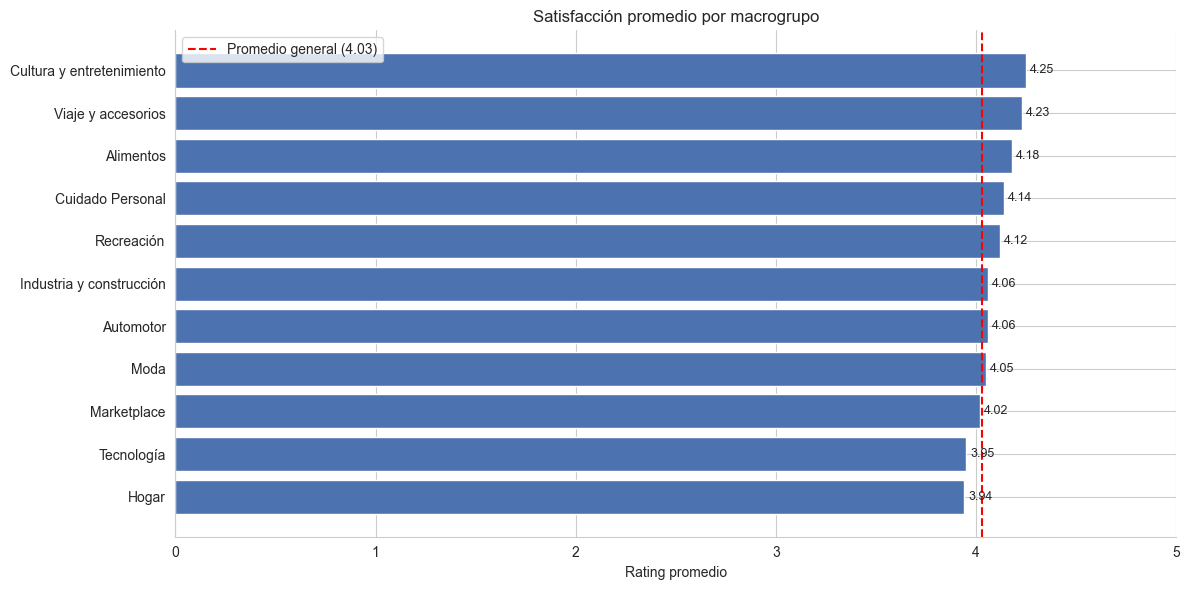

In [11]:
sns.set_style('whitegrid')
rating_orden = resumen.sort_values('rating_promedio', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(rating_orden['grupo_categoria'], rating_orden['rating_promedio'], color='#4C72B0')
plt.gca().invert_yaxis()
plt.axvline(x=df_model['review_score'].mean(), color='red', linestyle='--', label=f'Promedio general ({df_model["review_score"].mean():.2f})')
plt.xlim(0, 5)
plt.title('Satisfacción promedio por macrogrupo')
plt.xlabel('Rating promedio')
plt.legend()
for bar, val in zip(bars, rating_orden['rating_promedio']):
    plt.text(val+0.02, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

La satisfacción es homogénea entre grupos — ratings entre 3.9 y 4.3. 
Ningún grupo está significativamente por debajo del promedio general. 
Esto significa que la satisfacción no descalifica a ningún grupo como candidato de recomendación, 
pero sí puede usarse como variable de contexto para priorizar entre grupos con score similar.

**La satisfacción es alta y homogénea — 
no descalifica ningún grupo pero diferencia grupos con score similar.**

## 6. Pregunta 3: ¿Hay patrones temporales relevantes?

Se analizan las variables temporales construidas en el ETL para identificar 
momentos de mayor actividad de compra.

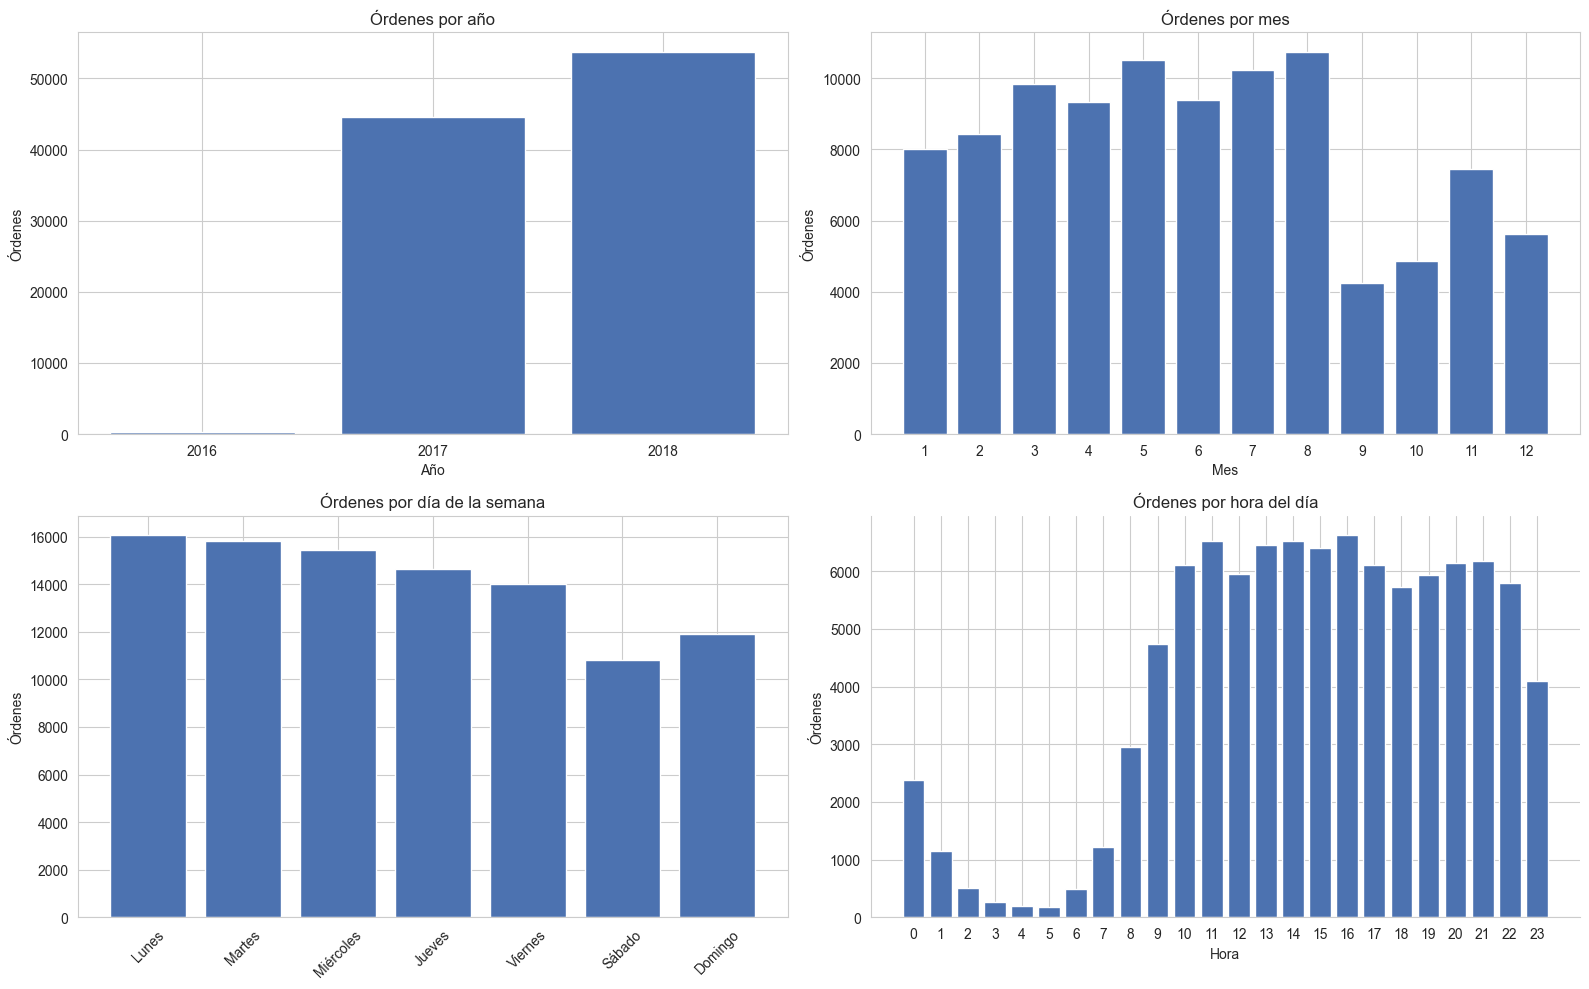

In [12]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Por año
ordenes_año = df_model.groupby('year')['order_id'].nunique()
axes[0,0].bar(ordenes_año.index.astype(str), ordenes_año.values, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Órdenes por año')
axes[0,0].set_xlabel('Año')
axes[0,0].set_ylabel('Órdenes')

# Por mes
ordenes_mes = df_model.groupby('month')['order_id'].nunique()
axes[0,1].bar(ordenes_mes.index, ordenes_mes.values, color='#4C72B0', edgecolor='white')
axes[0,1].set_title('Órdenes por mes')
axes[0,1].set_xlabel('Mes')
axes[0,1].set_ylabel('Órdenes')
axes[0,1].set_xticks(range(1,13))

# Por día de semana
dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
ordenes_dia = df_model.groupby('day_of_week')['order_id'].nunique()
axes[1,0].bar([dias[d] for d in ordenes_dia.index], ordenes_dia.values, color='#4C72B0', edgecolor='white')
axes[1,0].set_title('Órdenes por día de la semana')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylabel('Órdenes')

# Por hora
ordenes_hora = df_model.groupby('hour')['order_id'].nunique()
axes[1,1].bar(ordenes_hora.index, ordenes_hora.values, color='#4C72B0', edgecolor='white')
axes[1,1].set_title('Órdenes por hora del día')
axes[1,1].set_xlabel('Hora')
axes[1,1].set_ylabel('Órdenes')
axes[1,1].set_xticks(range(0,24))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Los patrones temporales son consistentes y accionables:

- **Crecimiento anual:** el marketplace está en expansión — más datos disponibles cada año
- **Estacionalidad mensual:** hay meses de mayor actividad que podrían usarse para 
activar recomendaciones en momentos clave
- **Días entre semana:** concentran más compras que fines de semana — 
perfil de comprador que navega en horario laboral
- **Pico horario:** entre 10h y 22h — ventana principal de actividad

**sí hay patrones temporales relevantes. 
Las variables year, month, day_of_week y hour están disponibles en el dataset 
para enriquecer el modelo en versiones futuras.**

## 7. Pregunta 2: ¿Existe co-ocurrencia suficiente entre grupos?

Esta es la pregunta más crítica. Se analiza cuántas órdenes contienen más de un macrogrupo 
y con qué frecuencia aparece cada par — este análisis es el insumo directo del modelo.

In [13]:
df_sin_other = df_model[df_model['grupo_categoria'] != 'other']
grupos_por_orden = df_sin_other.groupby('order_id')['grupo_categoria'].nunique()

print('=== ÓRDENES POR NÚMERO DE MACROGRUPOS ===')
print(f'  1 solo grupo:    {(grupos_por_orden==1).sum():,} ({(grupos_por_orden==1).mean()*100:.1f}%)')
print(f'  2 grupos:        {(grupos_por_orden==2).sum():,} ({(grupos_por_orden==2).mean()*100:.1f}%)')
print(f'  3+ grupos:       {(grupos_por_orden>=3).sum():,} ({(grupos_por_orden>=3).mean()*100:.1f}%)')
print()

# Calcular pares
pares = []
for grupos in df_sin_other.groupby('order_id')['grupo_categoria'].unique():
    if len(grupos) > 1:
        pares.extend(combinations(sorted(grupos), 2))

conteo_pares = Counter(pares)
cross_selling = (
    pd.DataFrame(conteo_pares.items(), columns=['par','frecuencia'])
    .sort_values('frecuencia', ascending=False)
    .reset_index(drop=True)
)

print(f'Total pares con co-ocurrencia: {len(cross_selling)}')
print()
print('Top 15 pares más frecuentes:')
print(cross_selling.head(15).to_string(index=False))

=== ÓRDENES POR NÚMERO DE MACROGRUPOS ===
  1 solo grupo:    96,584 (99.6%)
  2 grupos:        384 (0.4%)
  3+ grupos:       6 (0.0%)

Total pares con co-ocurrencia: 42

Top 15 pares más frecuentes:
                                   par  frecuencia
                   (Hogar, Recreación)          84
                   (Hogar, Tecnología)          31
     (Hogar, Industria y construcción)          30
        (Cuidado Personal, Recreación)          25
              (Recreación, Tecnología)          23
             (Cuidado Personal, Hogar)          20
                    (Moda, Recreación)          14
                         (Hogar, Moda)          12
    (Cultura y entretenimiento, Hogar)          12
                    (Moda, Tecnología)          11
                    (Automotor, Hogar)          10
(Industria y construcción, Recreación)          10
               (Automotor, Tecnología)          10
           (Hogar, Viaje y accesorios)           9
      (Recreación, Viaje y accesorio

In [14]:
# Productos por orden por macrogrupo
prod_por_orden_grupo = (
    df_sin_other
    .groupby(['grupo_categoria','order_id'])['order_item_id']
    .count()
    .reset_index(name='productos_por_orden')
    .groupby('grupo_categoria')['productos_por_orden']
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

print('=== PROMEDIO DE PRODUCTOS POR ORDEN POR GRUPO ===')
print(prod_por_orden_grupo.to_string())

=== PROMEDIO DE PRODUCTOS POR ORDEN POR GRUPO ===
grupo_categoria
Hogar                        1.224
Industria y construcción     1.220
Alimentos                    1.199
Tecnología                   1.125
Marketplace                  1.111
Cuidado Personal             1.095
Recreación                   1.092
Automotor                    1.088
Viaje y accesorios           1.081
Moda                         1.076
Cultura y entretenimiento    1.068


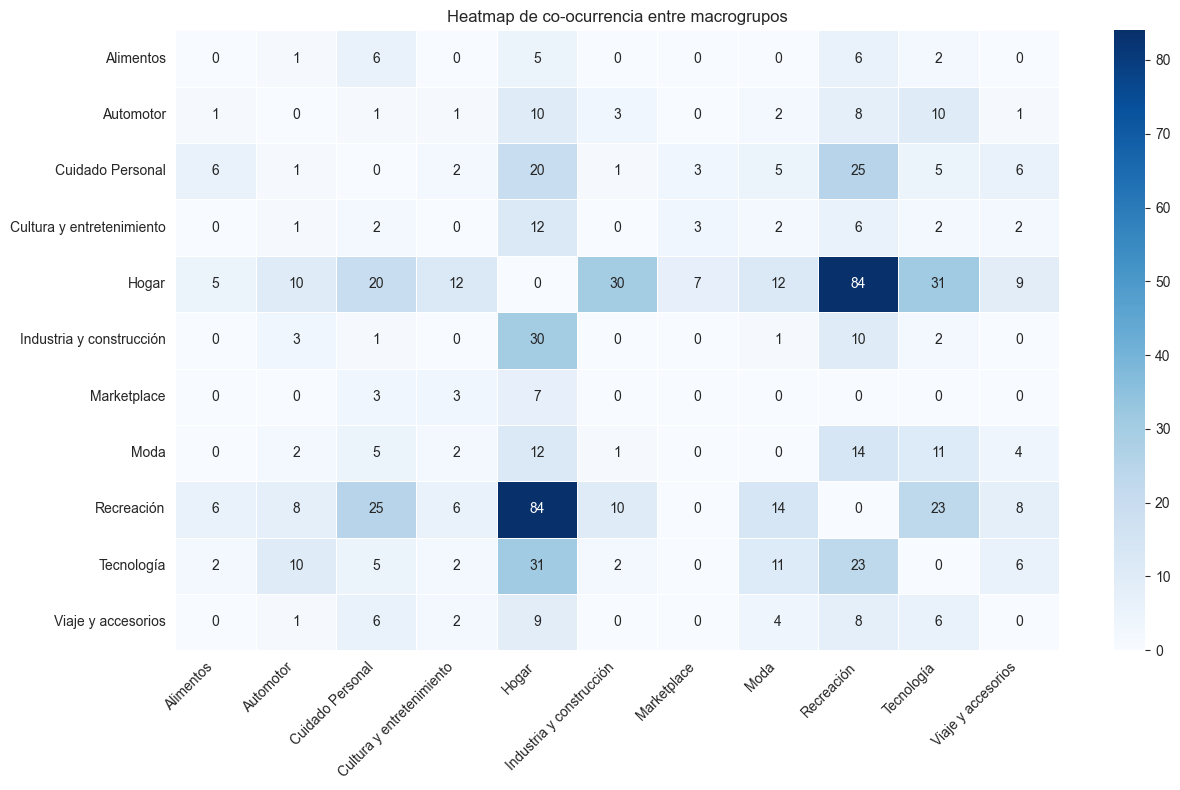

In [15]:
sns.set_style('whitegrid')
# Heatmap de co-ocurrencia
grupos = sorted(df_sin_other['grupo_categoria'].unique())
matriz = pd.DataFrame(0, index=grupos, columns=grupos)

for (g1,g2), freq in conteo_pares.items():
    matriz.loc[g1,g2] = freq
    matriz.loc[g2,g1] = freq

plt.figure(figsize=(13, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Heatmap de co-ocurrencia entre macrogrupos')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La co-ocurrencia es la variable más importante del modelo y también la más limitada:

- La mayoría de órdenes tienen un solo macrogrupo — limitación estructural del dataset
- Sin embargo, los pares que sí existen muestran patrones claros y consistentes
- **Hogar** es el grupo central: aparece en los pares más frecuentes con casi todos los demás grupos
- Hogar-Recreación es consistentemente el par más frecuente
- El heatmap muestra que hay suficientes pares con frecuencia > 5 para construir el modelo

**La co-ocurrencia es limitada pero existente y con patrones claros. 
Es suficiente para construir un modelo baseline de reglas confiable.**

## 8. Resumen Integrado — Insumos para el Modelo

Con las 5 preguntas respondidas, se consolida la tabla de métricas por macrogrupo 
que será el insumo directo del modelo de recomendación. 
Esta tabla representa la síntesis del EDA y el punto de partida del modelado.

In [16]:
print('=== TABLA DE INSUMOS PARA EL MODELO ===')
print(f'{"Grupo":<30} {"Órdenes":>8} {"Ingresos":>12} {"Ticket":>8} {"Rating":>7} {"Productos":>10}')
print('-' * 80)
for _, row in resumen.iterrows():
    print(f"{row['grupo_categoria']:<30} {row['ordenes']:>8,} "
          f"R${row['ingresos']:>10,.0f} "
          f"R${row['ticket_promedio']:>6.0f} "
          f"{row['rating_promedio']:>7.2f} "
          f"{row['productos_unicos']:>10,}")

print()
print('Variables que usará el modelo:')
print('  frecuencia de co-ocurrencia  → qué grupos recomendar')
print('  ticket_promedio              → ponderar por valor económico')
print('  rating_promedio              → validar experiencia del grupo recomendado')

=== TABLA DE INSUMOS PARA EL MODELO ===
Grupo                           Órdenes     Ingresos   Ticket  Rating  Productos
--------------------------------------------------------------------------------
Hogar                            30,171 R$ 3,921,401 R$   106    3.94     10,687
Recreación                       19,780 R$ 2,735,866 R$   127    4.12      6,705
Tecnología                       15,311 R$ 1,898,588 R$   110    3.95      3,820
Cuidado Personal                 12,013 R$ 1,660,798 R$   126    4.14      3,324
Moda                              7,993 R$ 1,405,797 R$   163    4.05      2,523
Automotor                         3,897 R$   592,918 R$   140    4.06      1,900
Viaje y accesorios                3,340 R$   371,434 R$   103    4.23      1,198
Industria y construcción          1,813 R$   376,747 R$   170    4.06        843
Cultura y entretenimiento         1,798 R$   303,166 R$   158    4.25        806
Alimentos                           974 R$    67,041 R$    57    4.18

La tabla consolida las métricas validadas en el EDA. 
Para el modelo de recomendación se usarán:

- **Frecuencia de co-ocurrencia** — variable principal: qué grupos se compran juntos
- **Ticket promedio** — variable de ponderación: priorizar grupos de mayor valor económico
- **Rating promedio** — variable de contexto: desempate entre grupos con score similar

La forma exacta de combinar estas variables — pesos, normalización y criterios de corte — 
será definida y validada en el notebook de modelado.

## 9. Conclusión


|  |  | Implicación para el modelo |
|---|---|---|
| ¿Macrogrupos coherentes? | Sí | La unidad de análisis es válida |
| ¿Co-ocurrencia suficiente? | Limitada pero existente | Modelo baseline viable, no modelo ML complejo |
| ¿Patrones temporales? | Sí | Variables disponibles para versiones futuras |
| ¿Ticket varía entre grupos? | Sí, hasta 3x | Debe incluirse como variable de ponderación |
| ¿Satisfacción difiere? | Homogénea y alta | Variable de contexto, no de descarte |

### Hallazgos adicionales que impactan el modelo

- **Hogar es el grupo ancla** — aparece en los pares más frecuentes de co-ocurrencia. 
Las recomendaciones más confiables serán las que involucren a Hogar
- **Ingresos, volumen y valor son independientes** — el modelo debe balancear las tres dimensiones
- **El precio no predice satisfacción** — el ticket promedio se usa como proxy de valor, no de calidad

### Variables validadas para el modelado

| Variable | Rol | Validación |
|---|---|---|
| `grupo_categoria` | Unidad de análisis | Grupos coherentes y diferenciados |
| `order_id` | Identifica co-ocurrencia | Pares con patrones claros |
| `price` → `ticket_promedio` | Ponderación por valor | Variación significativa entre grupos |
| `review_score` → `rating_promedio` | Contexto de calidad | Homogéneo, útil para desempate |

### Pregunta que guía el notebook 03

> *¿Cómo combinar la frecuencia de co-ocurrencia y el ticket promedio en un score 
que maximice tanto la relevancia como el valor económico de la recomendación, 
dado que la co-ocurrencia es limitada?*